<a href="https://colab.research.google.com/github/iqlore-collab/housing-market-intelligence-supervised-unsupervised-ml-public/blob/main/housing_regression_supervised_only.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/" target="_parent">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# 🏡 Housing Price Regression — Portfolio Notebook

This notebook is focused on **one clear machine learning task**: predicting `SalePrice` for houses.

I keep the workflow clean and practical, like a real GitHub project:

- load the housing dataset from Google Drive,
- explore the data,
- engineer stronger housing-market features,
- build a baseline,
- train multiple regression models,
- compare them with real metrics,
- explain what drives price predictions.

The goal is simple but exciting: **turn raw housing data into a model that can estimate real estate prices.**

---
## 1. Setup and dataset loading

I start by mounting Google Drive and loading the exact dataset used for this project.

The notebook uses only this file:

```text
/content/drive/MyDrive/Colab Notebooks/housing_iteration_6_regression.csv
```

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

RANDOM_STATE = 42
TARGET = "SalePrice"
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/housing_iteration_6_regression.csv"

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [3]:
housing = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print(f"Dataset path: {DATA_PATH}")
print(f"Dataset shape: {housing.shape}")

housing.head()

Dataset loaded successfully!
Dataset path: /content/drive/MyDrive/Colab Notebooks/housing_iteration_6_regression.csv
Dataset shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.00,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,"2,003.00",RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.00,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,"1,976.00",RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.00,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,"2,001.00",RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.00,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.00,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,"1,998.00",Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.00,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.00,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,"2,000.00",RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


---
## 2. First look at the data

Before modeling, I check the structure of the dataset. I want to understand the target, missing values, and the most important numerical patterns.

In [4]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
housing.describe().T.head(25)

,count,mean,std,min,25%,50%,75%,max
Id,"1,460.00",730.50,421.61,1.00,365.75,730.50,"1,095.25","1,460.00"
MSSubClass,"1,460.00",56.90,42.30,20.00,20.00,50.00,70.00,190.00
LotFrontage,"1,201.00",70.05,24.28,21.00,59.00,69.00,80.00,313.00
LotArea,"1,460.00","10,516.83","9,981.26","1,300.00","7,553.50","9,478.50","11,601.50","215,245.00"
OverallQual,"1,460.00",6.10,1.38,1.00,5.00,6.00,7.00,10.00
OverallCond,"1,460.00",5.58,1.11,1.00,5.00,5.00,6.00,9.00
YearBuilt,"1,460.00","1,971.27",30.20,"1,872.00","1,954.00","1,973.00","2,000.00","2,010.00"
YearRemodAdd,"1,460.00","1,984.87",20.65,"1,950.00","1,967.00","1,994.00","2,004.00","2,010.00"
MasVnrArea,"1,452.00",103.69,181.07,0.00,0.00,0.00,166.00,"1,600.00"
BsmtFinSF1,"1,460.00",443.64,456.10,0.00,0.00,383.50,712.25,"5,644.00"


In [6]:
if TARGET not in housing.columns:
    raise ValueError(f"The target column '{TARGET}' is missing from the dataset.")

missing_values = (
    housing.isna()
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

missing_values

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


Missing values are expected in this housing dataset because not every house has a basement, garage, fireplace, or pool. Instead of dropping useful rows, I handle missing values inside preprocessing pipelines.

---
### Visual data quality check

Before building models, I want to actually **see** the dataset quality. Tables are useful, but plots make missing values, feature types, and potential issues much easier to catch.

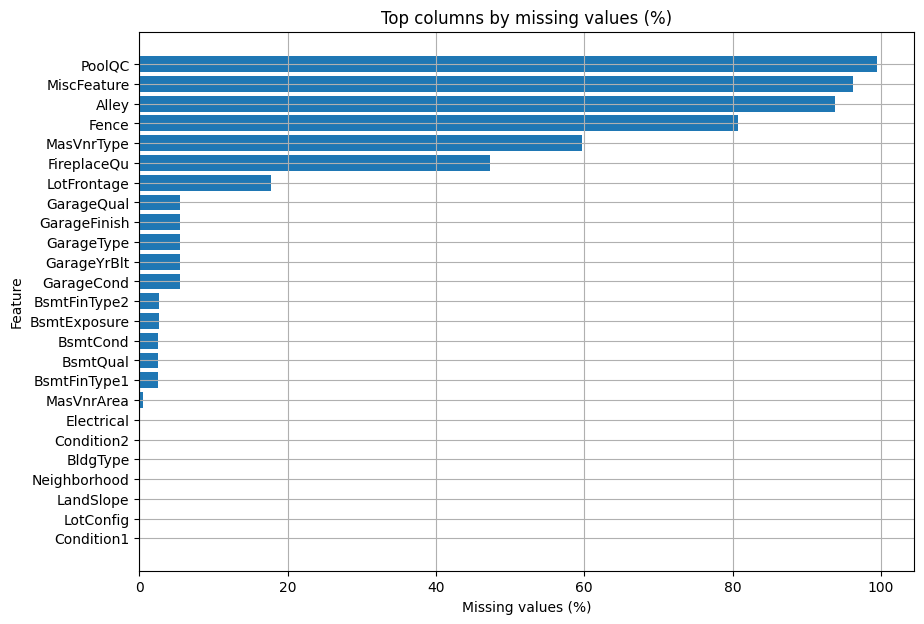

In [7]:
# Missing values overview
missing_plot = (
    housing.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .head(25)
)

plt.figure(figsize=(10, 7))
plt.barh(missing_plot.index[::-1], missing_plot.values[::-1])
plt.title("Top columns by missing values (%)")
plt.xlabel("Missing values (%)")
plt.ylabel("Feature")
plt.show()

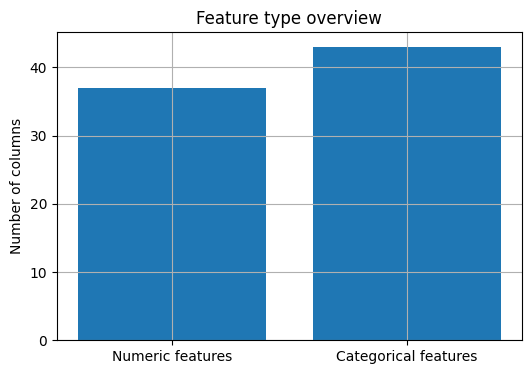

In [8]:
# Numeric vs categorical feature count
feature_types = housing.drop(columns=[TARGET], errors="ignore").dtypes.astype(str)
feature_groups = pd.Series({
    "Numeric features": housing.drop(columns=[TARGET], errors="ignore").select_dtypes(include="number").shape[1],
    "Categorical features": housing.drop(columns=[TARGET], errors="ignore").select_dtypes(exclude="number").shape[1]
})

plt.figure(figsize=(6, 4))
plt.bar(feature_groups.index, feature_groups.values)
plt.title("Feature type overview")
plt.ylabel("Number of columns")
plt.show()

---
## 3. Target exploration

The target is `SalePrice`, so I check both the original price distribution and a log-transformed version. The log view often makes housing prices easier to understand because prices are usually right-skewed.

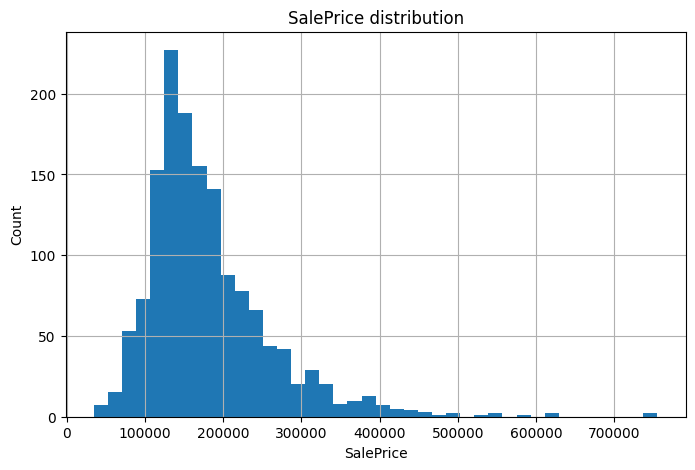

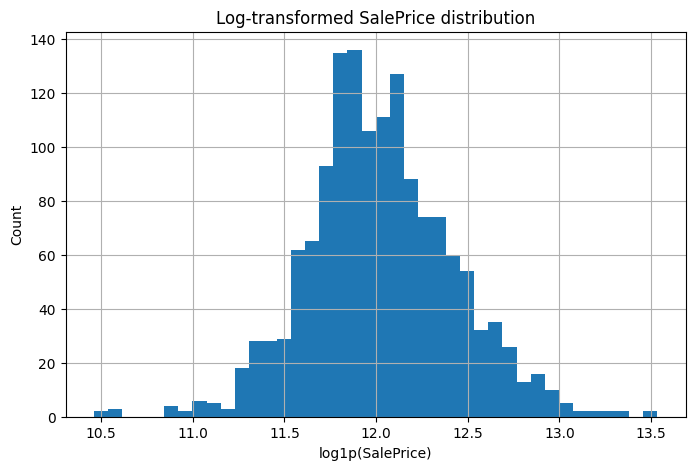

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(housing[TARGET], bins=40)
plt.title("SalePrice distribution")
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(np.log1p(housing[TARGET]), bins=40)
plt.title("Log-transformed SalePrice distribution")
plt.xlabel("log1p(SalePrice)")
plt.ylabel("Count")
plt.show()

In [10]:
important_numeric_columns = [
    col for col in ["OverallQual", "GrLivArea", "GarageCars", "GarageArea", "TotalBsmtSF", "1stFlrSF", "YearBuilt"]
    if col in housing.columns
]

correlations = (
    housing[important_numeric_columns + [TARGET]]
    .corr(numeric_only=True)[TARGET]
    .sort_values(ascending=False)
)

correlations

,SalePrice
SalePrice,1.00
OverallQual,0.79
GrLivArea,0.71
GarageCars,0.64
GarageArea,0.62
TotalBsmtSF,0.61
1stFlrSF,0.61
YearBuilt,0.52


---
### Stronger EDA: price drivers

Now I dig deeper into the most important visual relationships. This is the part where the housing market starts to make sense: quality, size, age, garage space, and neighborhood signals usually explain a lot of price movement.

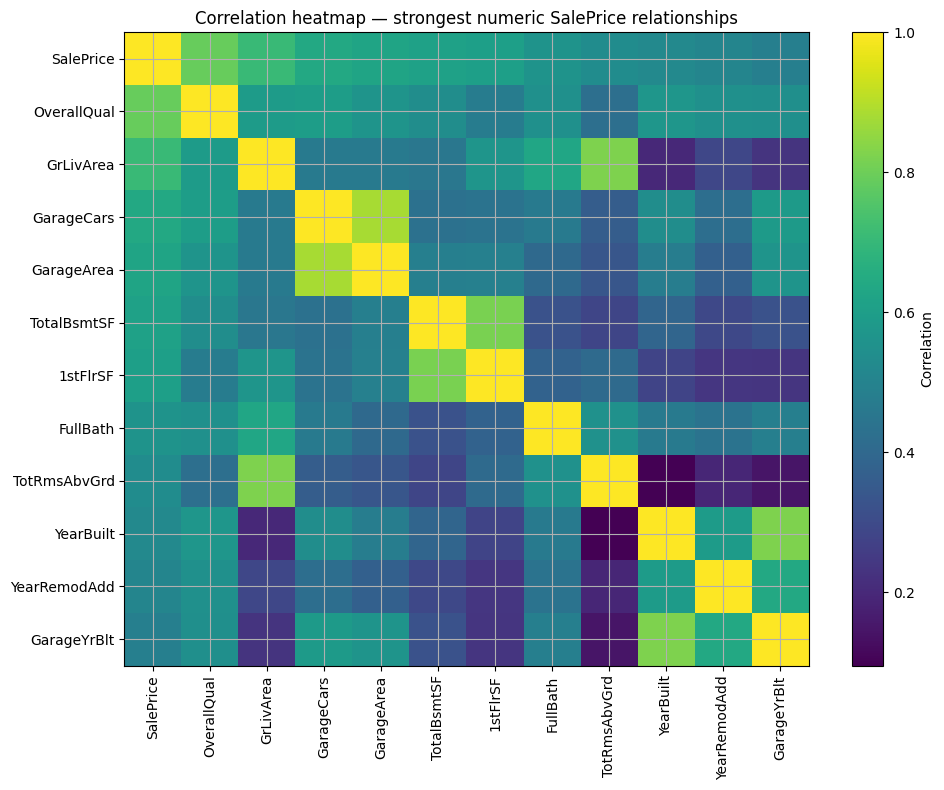

,SalePrice,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,YearRemodAdd,GarageYrBlt
SalePrice,1.00,0.79,0.71,0.64,0.62,0.61,0.61,0.56,0.53,0.52,0.51,0.49
OverallQual,0.79,1.00,0.59,0.60,0.56,0.54,0.48,0.55,0.43,0.57,0.55,0.55
GrLivArea,0.71,0.59,1.00,0.47,0.47,0.45,0.57,0.63,0.83,0.20,0.29,0.23
GarageCars,0.64,0.60,0.47,1.00,0.88,0.43,0.44,0.47,0.36,0.54,0.42,0.59
GarageArea,0.62,0.56,0.47,0.88,1.00,0.49,0.49,0.41,0.34,0.48,0.37,0.56
TotalBsmtSF,0.61,0.54,0.45,0.43,0.49,1.00,0.82,0.32,0.29,0.39,0.29,0.32
1stFlrSF,0.61,0.48,0.57,0.44,0.49,0.82,1.00,0.38,0.41,0.28,0.24,0.23
FullBath,0.56,0.55,0.63,0.47,0.41,0.32,0.38,1.00,0.55,0.47,0.44,0.48
TotRmsAbvGrd,0.53,0.43,0.83,0.36,0.34,0.29,0.41,0.55,1.00,0.10,0.19,0.15
YearBuilt,0.52,0.57,0.20,0.54,0.48,0.39,0.28,0.47,0.10,1.00,0.59,0.83


In [11]:
# Correlation heatmap for the strongest numeric predictors
numeric_df = housing.select_dtypes(include="number")

if TARGET in numeric_df.columns:
    top_corr_features = (
        numeric_df.corr(numeric_only=True)[TARGET]
        .abs()
        .sort_values(ascending=False)
        .head(12)
        .index
    )

    corr_matrix = numeric_df[top_corr_features].corr(numeric_only=True)

    plt.figure(figsize=(10, 8))
    plt.imshow(corr_matrix, aspect="auto")
    plt.colorbar(label="Correlation")
    plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
    plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
    plt.title("Correlation heatmap — strongest numeric SalePrice relationships")
    plt.tight_layout()
    plt.show()

    display(corr_matrix.round(2))

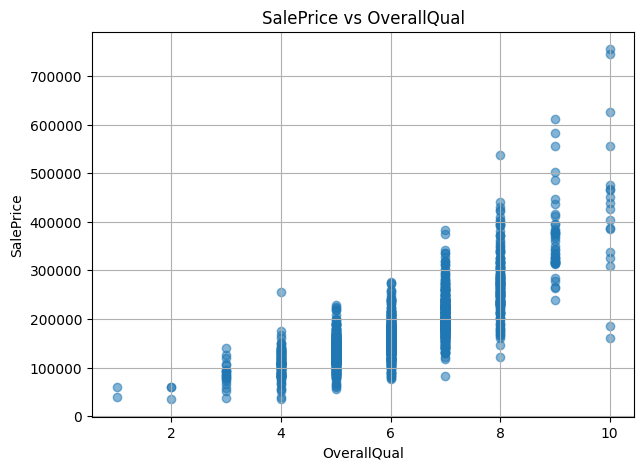

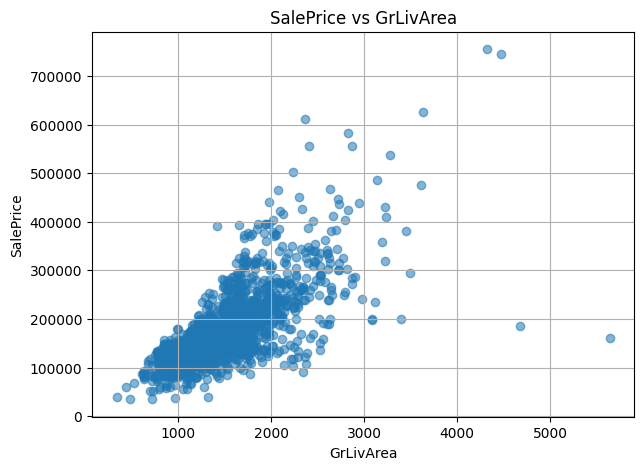

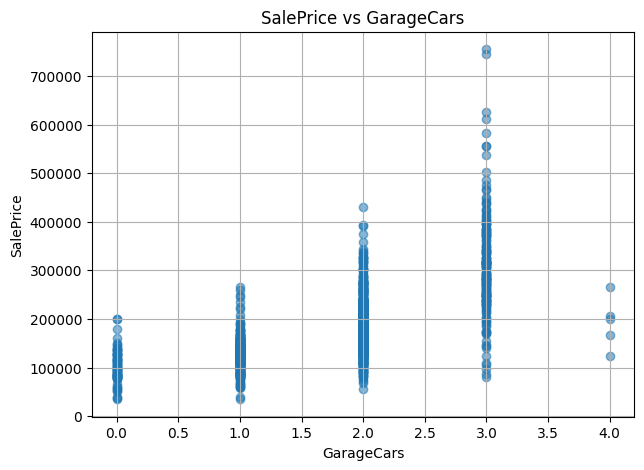

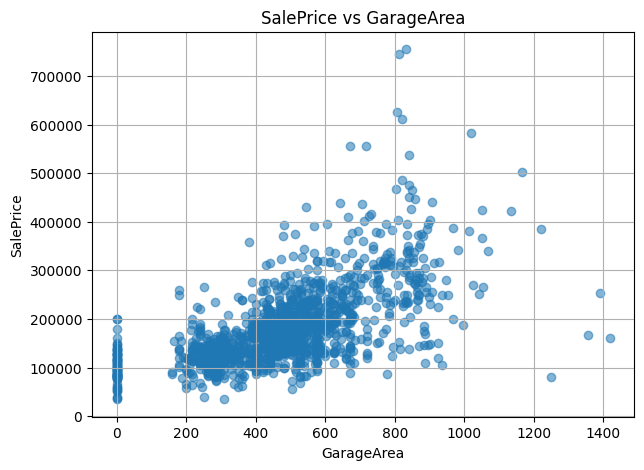

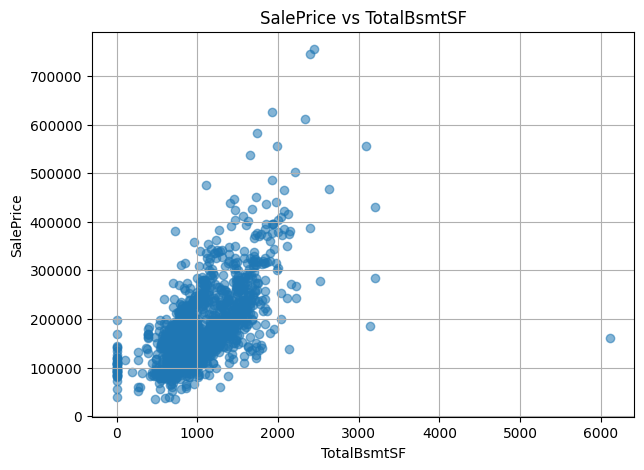

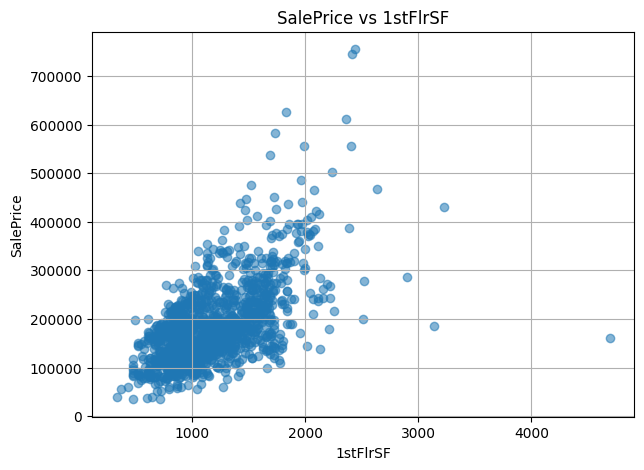

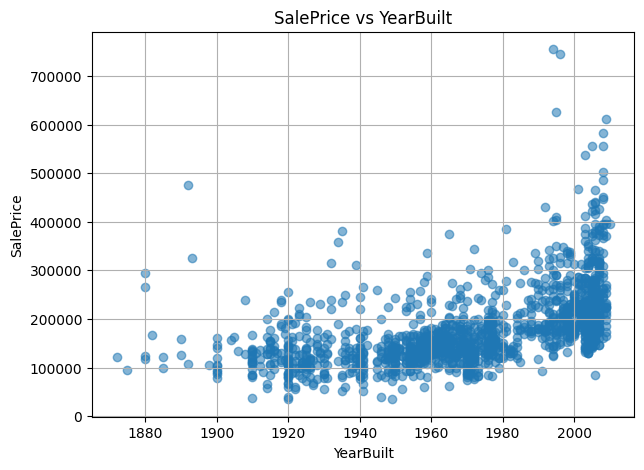

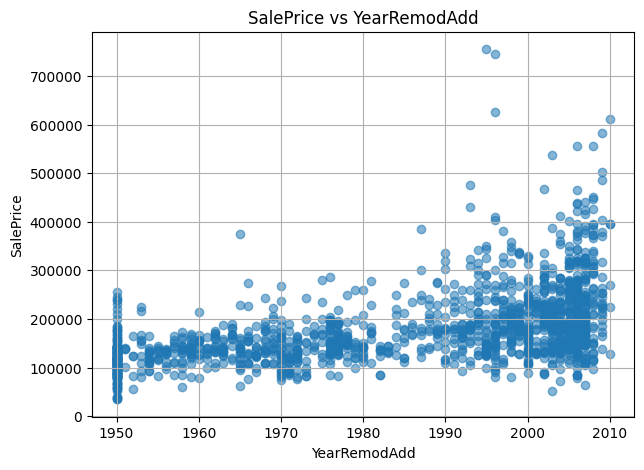

In [12]:
# Scatterplots for major numeric price drivers
scatter_features = [
    "OverallQual", "GrLivArea", "GarageCars", "GarageArea",
    "TotalBsmtSF", "1stFlrSF", "YearBuilt", "YearRemodAdd"
]
scatter_features = [col for col in scatter_features if col in housing.columns]

for col in scatter_features:
    plt.figure(figsize=(7, 5))
    plt.scatter(housing[col], housing[TARGET], alpha=0.55)
    plt.title(f"SalePrice vs {col}")
    plt.xlabel(col)
    plt.ylabel("SalePrice")
    plt.show()

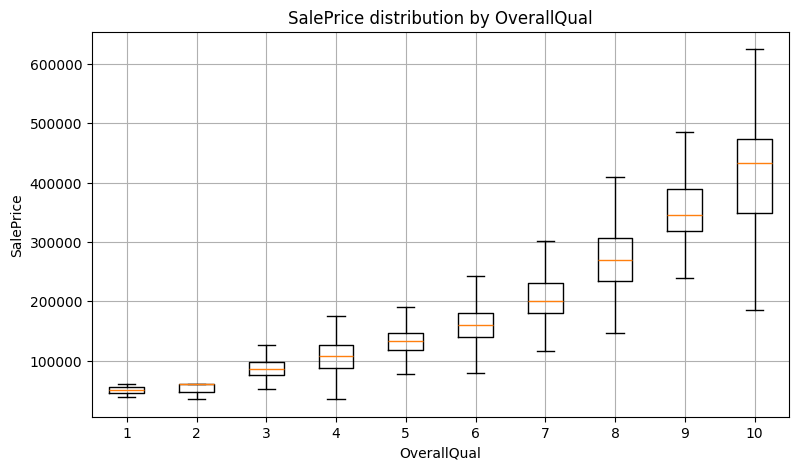

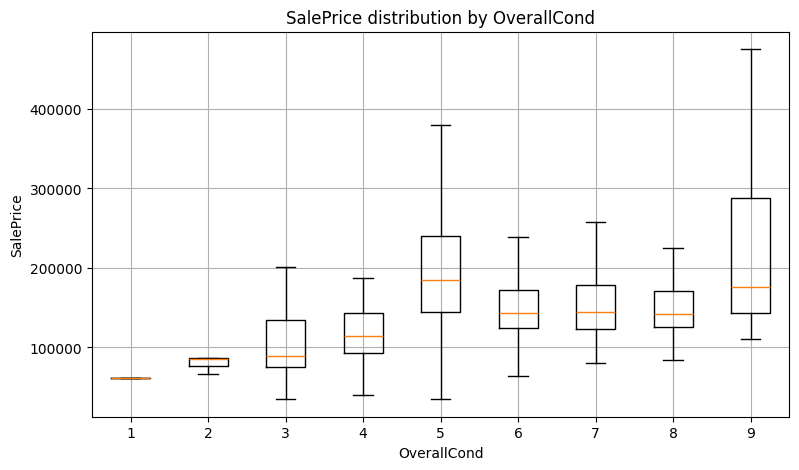

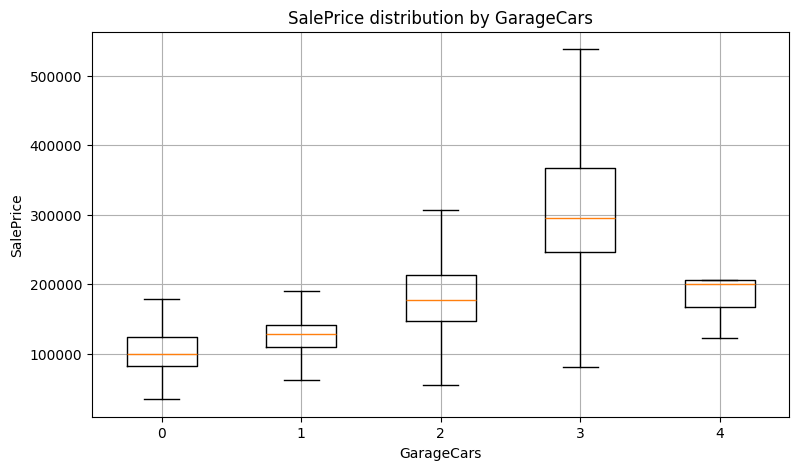

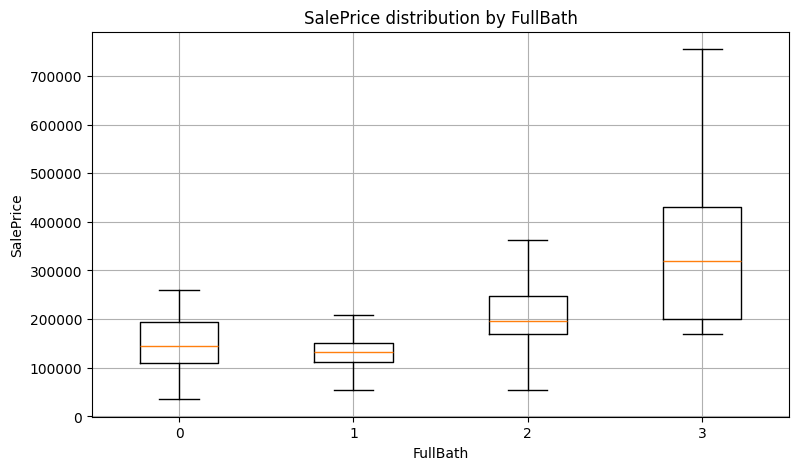

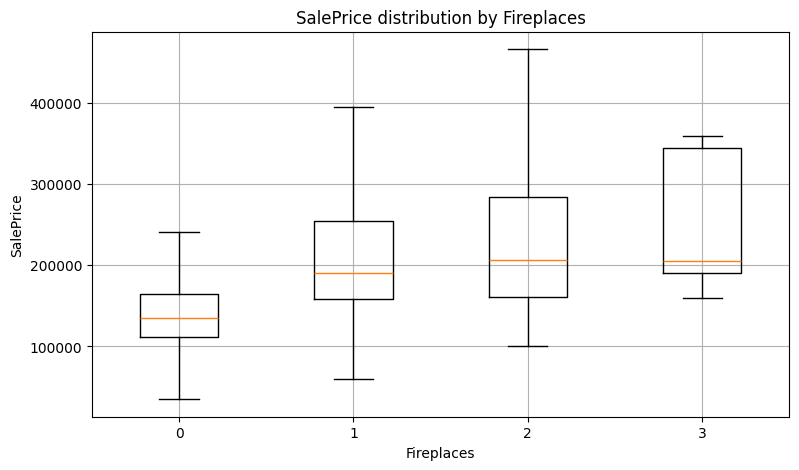

In [13]:
# Boxplots for categorical/ordinal housing quality features
boxplot_features = ["OverallQual", "OverallCond", "GarageCars", "FullBath", "Fireplaces"]
boxplot_features = [col for col in boxplot_features if col in housing.columns]

for col in boxplot_features:
    plot_data = housing[[col, TARGET]].dropna().copy()
    categories = sorted(plot_data[col].unique())
    grouped_prices = [plot_data.loc[plot_data[col] == value, TARGET] for value in categories]

    plt.figure(figsize=(9, 5))
    plt.boxplot(grouped_prices, labels=categories, showfliers=False)
    plt.title(f"SalePrice distribution by {col}")
    plt.xlabel(col)
    plt.ylabel("SalePrice")
    plt.show()

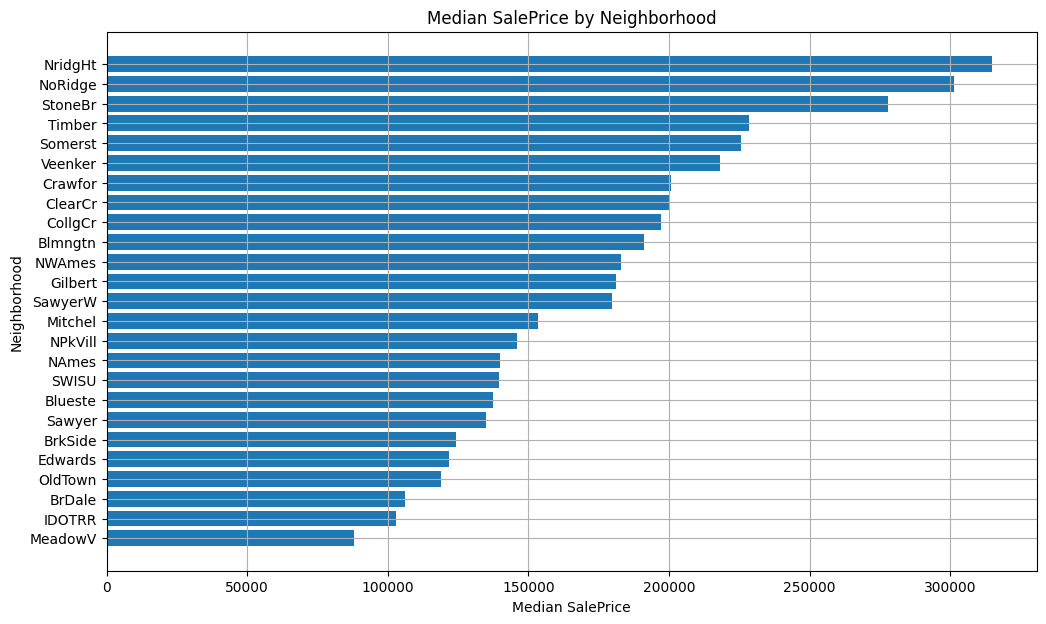

In [14]:
# Neighborhood price comparison, if the column exists
if "Neighborhood" in housing.columns:
    neighborhood_prices = (
        housing.groupby("Neighborhood")[TARGET]
        .median()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(12, 7))
    plt.barh(neighborhood_prices.index[::-1], neighborhood_prices.values[::-1])
    plt.title("Median SalePrice by Neighborhood")
    plt.xlabel("Median SalePrice")
    plt.ylabel("Neighborhood")
    plt.show()

---
## 4. Feature engineering

This is where the project becomes more interesting. I create housing-specific features that make business sense:

- total square footage,
- total bathrooms,
- house age,
- years since remodeling,
- outdoor space,
- garage strength,
- quality × size interactions,
- a simple luxury signal.

These features help the model understand the property as a real housing-market object, not just a table of columns.

In [15]:
def safe_series(df, column, default=0):
    if column in df.columns:
        return df[column]
    return pd.Series(default, index=df.index)


def add_market_features(df):
    df = df.copy()

    df["TotalSF"] = (
        safe_series(df, "TotalBsmtSF").fillna(0)
        + safe_series(df, "1stFlrSF").fillna(0)
        + safe_series(df, "2ndFlrSF").fillna(0)
    )

    if "GrLivArea" in df.columns:
        df["TotalLivingAndBasement"] = (
            safe_series(df, "GrLivArea").fillna(0)
            + safe_series(df, "TotalBsmtSF").fillna(0)
        )

    df["TotalBathrooms"] = (
        safe_series(df, "FullBath").fillna(0)
        + 0.5 * safe_series(df, "HalfBath").fillna(0)
        + safe_series(df, "BsmtFullBath").fillna(0)
        + 0.5 * safe_series(df, "BsmtHalfBath").fillna(0)
    )

    if {"YrSold", "YearBuilt"}.issubset(df.columns):
        df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

    if {"YrSold", "YearRemodAdd"}.issubset(df.columns):
        df["YearsSinceRemod"] = df["YrSold"] - df["YearRemodAdd"]

    df["OutdoorSF"] = (
        safe_series(df, "WoodDeckSF").fillna(0)
        + safe_series(df, "OpenPorchSF").fillna(0)
        + safe_series(df, "EnclosedPorch").fillna(0)
        + safe_series(df, "3SsnPorch").fillna(0)
        + safe_series(df, "ScreenPorch").fillna(0)
    )

    df["GarageScore"] = (
        safe_series(df, "GarageCars").fillna(0)
        * safe_series(df, "GarageArea").fillna(0)
    )

    if {"OverallQual", "TotalSF"}.issubset(df.columns):
        df["QualityTotalSF"] = df["OverallQual"] * df["TotalSF"]

    if {"OverallQual", "GrLivArea"}.issubset(df.columns):
        df["QualityGrLivArea"] = df["OverallQual"] * df["GrLivArea"]

    if {"OverallQual", "GarageCars"}.issubset(df.columns):
        df["QualityGarage"] = df["OverallQual"] * safe_series(df, "GarageCars").fillna(0)

    df["LuxurySignal"] = (
        (safe_series(df, "OverallQual") >= 7).astype(int)
        + (safe_series(df, "GarageCars").fillna(0) >= 2).astype(int)
        + (safe_series(df, "Fireplaces").fillna(0) > 0).astype(int)
        + (df["TotalBathrooms"] >= 2.5).astype(int)
    )

    if {"TotalBsmtSF", "1stFlrSF"}.issubset(df.columns):
        df["BasementRatio"] = df["TotalBsmtSF"].fillna(0) / df["1stFlrSF"].replace(0, np.nan)

    return df.replace([np.inf, -np.inf], np.nan)


housing_fe = add_market_features(housing)

print("Shape before feature engineering:", housing.shape)
print("Shape after feature engineering:", housing_fe.shape)

housing_fe.head()

Shape before feature engineering: (1460, 81)
Shape after feature engineering: (1460, 93)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalSF,TotalLivingAndBasement,TotalBathrooms,HouseAge,YearsSinceRemod,OutdoorSF,GarageScore,QualityTotalSF,QualityGrLivArea,QualityGarage,LuxurySignal,BasementRatio
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.00,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,"2,003.00",RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,2566,2566,3.50,5,5,61,1096,17962,11970,14,3,1.00
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.00,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,"1,976.00",RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,2524,2524,2.50,31,31,298,920,15144,7572,12,3,1.00
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.00,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,"2,001.00",RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,2706,2706,3.50,7,6,42,1216,18942,12502,14,4,1.00
3,4,70,RL,60.00,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.00,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,"1,998.00",Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,2473,2473,2.00,91,36,307,1926,17311,12019,21,3,0.79
4,5,60,RL,84.00,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.00,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,"2,000.00",RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,3343,3343,3.50,8,8,276,2508,26744,17584,24,4,1.00


---
### Visual check of engineered features

After feature engineering, I check whether my new features actually carry a clear relationship with `SalePrice`. This is one of the most satisfying parts because the new variables should feel like real housing-market signals.

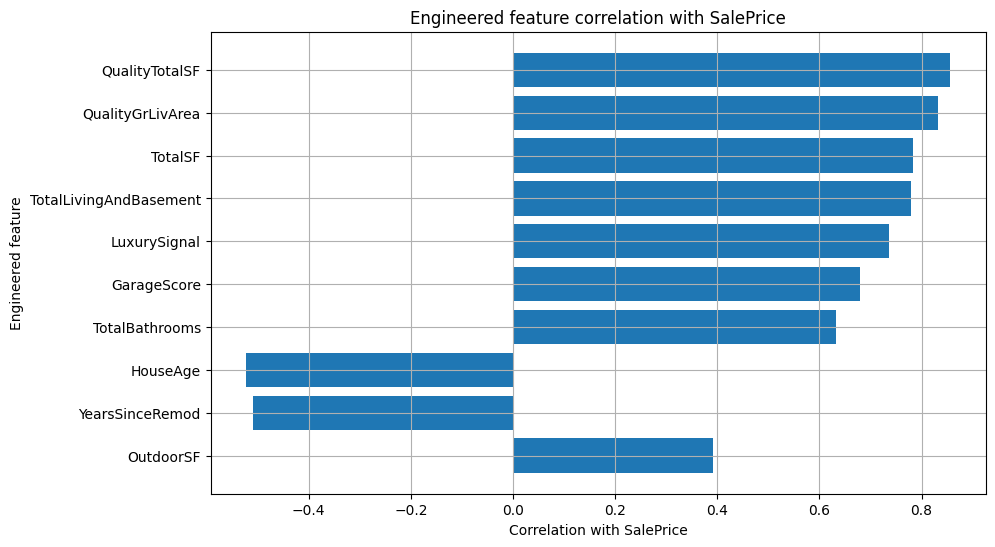

,Correlation with SalePrice
QualityTotalSF,0.86
QualityGrLivArea,0.83
TotalSF,0.78
TotalLivingAndBasement,0.78
LuxurySignal,0.74
GarageScore,0.68
TotalBathrooms,0.63
HouseAge,-0.52
YearsSinceRemod,-0.51
OutdoorSF,0.39


In [16]:
engineered_features = [
    "TotalSF", "TotalLivingAndBasement", "TotalBathrooms", "HouseAge",
    "YearsSinceRemod", "OutdoorSF", "GarageScore", "QualityTotalSF",
    "QualityGrLivArea", "LuxurySignal"
]
engineered_features = [col for col in engineered_features if col in housing_fe.columns]

engineered_corr = (
    housing_fe[engineered_features + [TARGET]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

plt.figure(figsize=(10, 6))
plt.barh(engineered_corr.index[::-1], engineered_corr.values[::-1])
plt.title("Engineered feature correlation with SalePrice")
plt.xlabel("Correlation with SalePrice")
plt.ylabel("Engineered feature")
plt.show()

display(engineered_corr.to_frame("Correlation with SalePrice"))

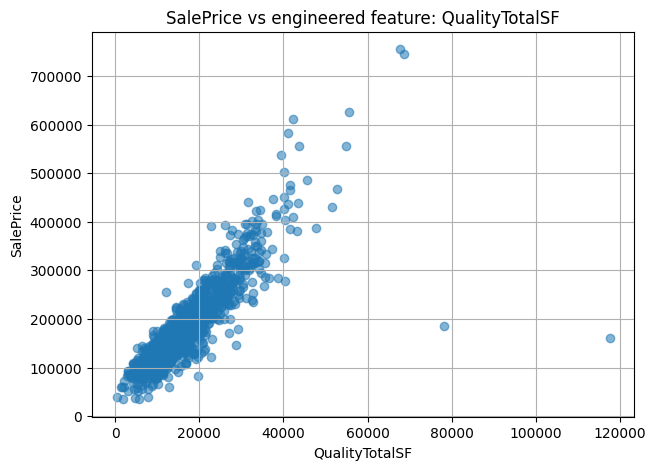

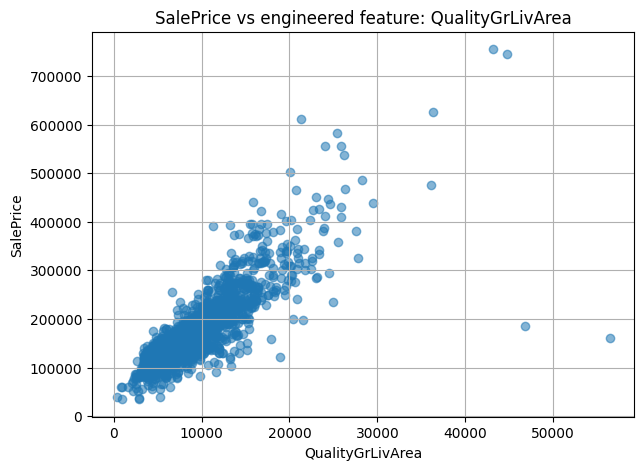

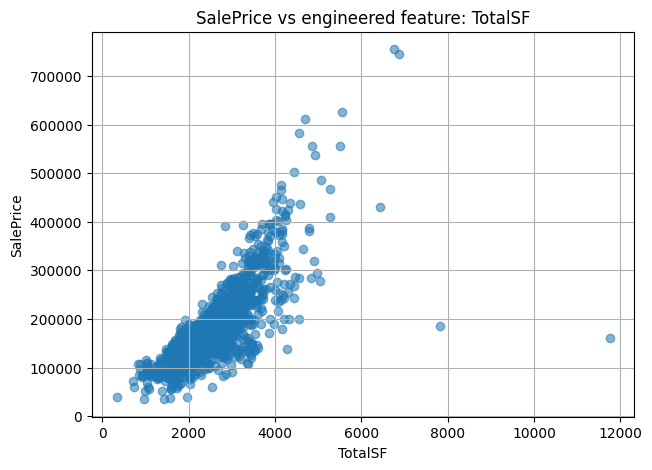

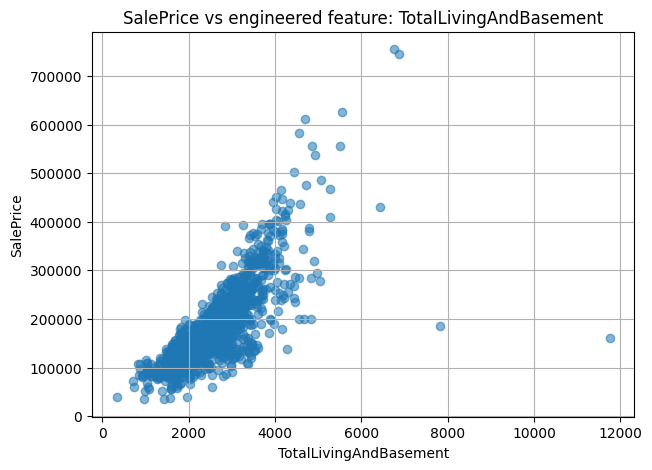

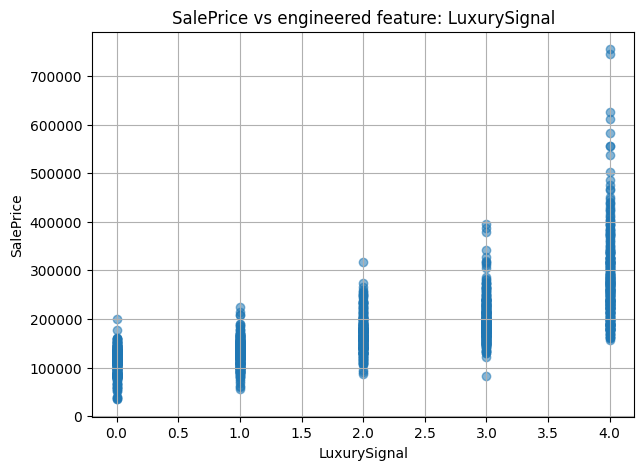

In [17]:
# Visualizing the strongest engineered features
for col in engineered_corr.head(5).index:
    plt.figure(figsize=(7, 5))
    plt.scatter(housing_fe[col], housing_fe[TARGET], alpha=0.55)
    plt.title(f"SalePrice vs engineered feature: {col}")
    plt.xlabel(col)
    plt.ylabel("SalePrice")
    plt.show()

---
## 5. Train/test split

I split the data before fitting any model. This keeps the test set unseen and gives me a fair estimate of how well the model generalizes.

I also remove a few extreme `GrLivArea` outliers because very large homes can distort the model.

In [18]:
if "GrLivArea" in housing_fe.columns:
    housing_model = housing_fe[housing_fe["GrLivArea"] < 4000].copy()
else:
    housing_model = housing_fe.copy()

X = housing_model.drop(columns=[TARGET])
y = housing_model[TARGET].astype(float)

X = X.drop(columns=["Id", "HouseID"], errors="ignore")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])
print("Features:", X_train.shape[1])

Training rows: 1164
Test rows: 292
Features: 91


---
## 6. Baseline model

Before I celebrate any machine learning model, I need a simple benchmark. Here the baseline predicts the median sale price from the training set.

This gives me a minimum standard: every serious model should beat this.

In [19]:
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5


def evaluate_predictions(model_name, y_true, y_pred):
    return {
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

baseline_pred = np.repeat(y_train.median(), len(y_test))
baseline_results = pd.DataFrame([
    evaluate_predictions("Median baseline", y_test, baseline_pred)
])

baseline_results

,model,MAE,RMSE,R2
0,Median baseline,"54,387.66","73,250.30",-0.02


---
## 7. Preprocessing pipeline

The dataset has numeric, ordinal, and nominal categorical features. I keep preprocessing inside a `Pipeline` so the workflow is clean and reproducible.

This is exactly the style I want in a portfolio notebook: no manual preprocessing leakage, no messy transformations outside the model pipeline.

In [20]:
QUALITY_ORDER = ["Missing", "Po", "Fa", "TA", "Gd", "Ex"]

ORDINAL_CANDIDATES = [
    "ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "KitchenQual",
    "FireplaceQu", "GarageQual", "GarageCond", "HeatingQC"
]


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor(X):
    numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

    ordinal_features = [c for c in ORDINAL_CANDIDATES if c in categorical_features]
    nominal_features = [c for c in categorical_features if c not in ordinal_features]

    transformers = []

    if numeric_features:
        numeric_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
        transformers.append(("num", numeric_pipe, numeric_features))

    if ordinal_features:
        ordinal_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("encoder", OrdinalEncoder(
                categories=[QUALITY_ORDER for _ in ordinal_features],
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ))
        ])
        transformers.append(("ord", ordinal_pipe, ordinal_features))

    if nominal_features:
        nominal_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", make_one_hot_encoder())
        ])
        transformers.append(("nom", nominal_pipe, nominal_features))

    return ColumnTransformer(transformers, remainder="drop")


preprocessor = build_preprocessor(X_train)

print("Preprocessor ready.")

Preprocessor ready.


---
## 8. Model training

Now I train several regression models and compare them fairly on the same test set:

- Ridge Regression,
- Decision Tree,
- Random Forest,
- Gradient Boosting.

I like this setup because it gives me both interpretability and stronger ensemble models.

In [21]:
models = {
    "Ridge Regression": Ridge(alpha=10),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        min_samples_leaf=20,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=150,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        min_samples_leaf=2
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=180,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    )
}

results = []
fitted_models = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", build_preprocessor(X_train)),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    predictions = pipe.predict(X_test)

    results.append(evaluate_predictions(name, y_test, predictions))
    fitted_models[name] = pipe

model_results = (
    pd.concat([baseline_results, pd.DataFrame(results)], ignore_index=True)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

model_results

,model,MAE,RMSE,R2
0,Ridge Regression,"14,951.62","20,581.70",0.92
1,Gradient Boosting,"15,244.77","22,858.66",0.90
2,Random Forest,"16,903.30","25,121.22",0.88
3,Decision Tree,"22,886.10","33,061.14",0.79
4,Median baseline,"54,387.66","73,250.30",-0.02


---
### Model comparison visualized

The table is useful, but the charts make the winner obvious. I compare RMSE, MAE, and R² so I can see both prediction error and explained variance.

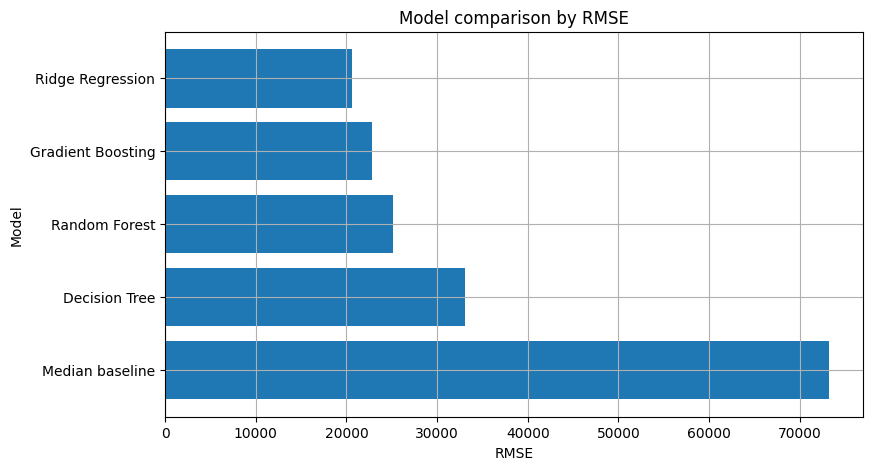

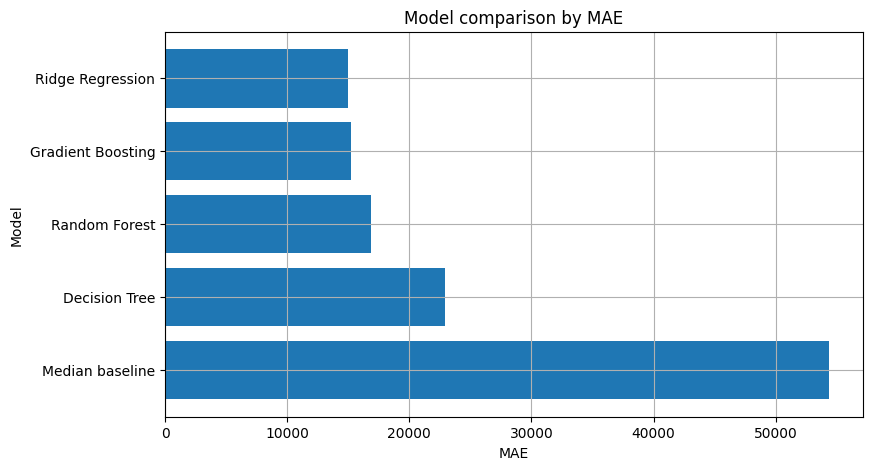

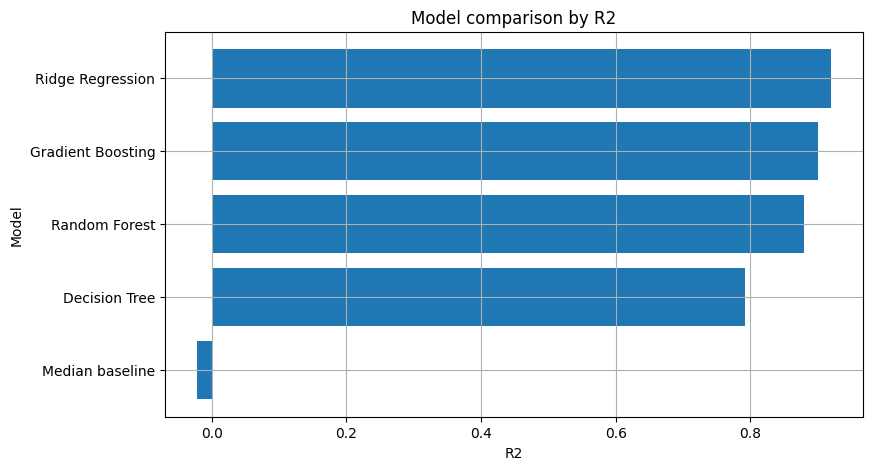

In [22]:
metrics_to_plot = ["RMSE", "MAE", "R2"]

for metric in metrics_to_plot:
    plot_df = model_results.sort_values(metric, ascending=(metric != "R2"))

    plt.figure(figsize=(9, 5))
    plt.barh(plot_df["model"][::-1], plot_df[metric][::-1])
    plt.title(f"Model comparison by {metric}")
    plt.xlabel(metric)
    plt.ylabel("Model")
    plt.show()

---
## 9. Best model diagnostics

After training, I inspect the best model more closely. I compare actual vs predicted prices and check residuals.

This tells me whether the model is making random-looking errors or missing a clear pattern.

Best model: Ridge Regression
MAE: 14951.62
RMSE: 20581.7
R2: 0.9193


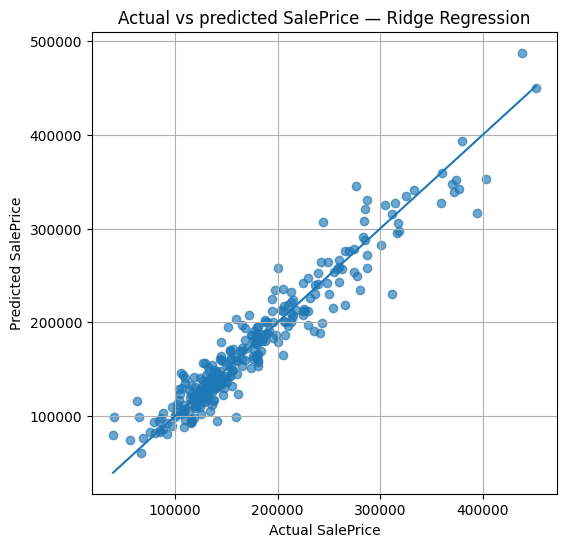

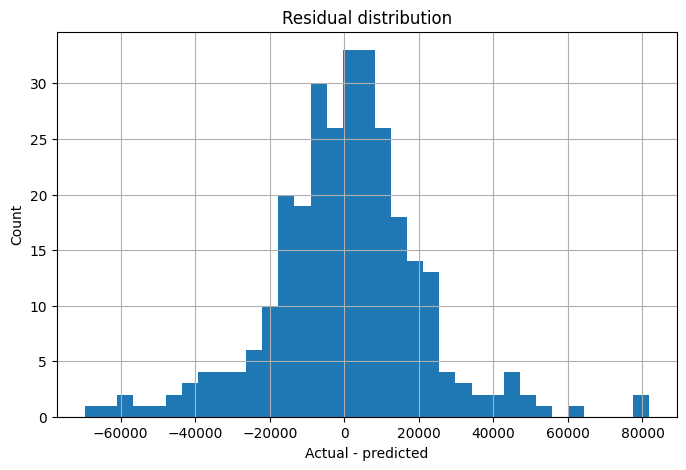

In [23]:
best_model_name = model_results[model_results["model"] != "Median baseline"].iloc[0]["model"]
best_model = fitted_models[best_model_name]

best_predictions = best_model.predict(X_test)

print("Best model:", best_model_name)
print("MAE:", round(mean_absolute_error(y_test, best_predictions), 2))
print("RMSE:", round(rmse(y_test, best_predictions), 2))
print("R2:", round(r2_score(y_test, best_predictions), 4))

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_predictions, alpha=0.65)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title(f"Actual vs predicted SalePrice — {best_model_name}")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.show()

residuals = y_test - best_predictions

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=35)
plt.title("Residual distribution")
plt.xlabel("Actual - predicted")
plt.ylabel("Count")
plt.show()

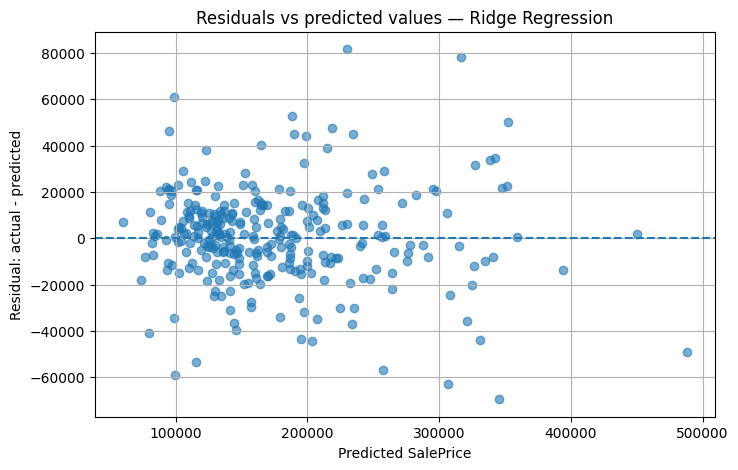

In [24]:
# Residuals vs predictions — this helps detect patterns in model errors
plt.figure(figsize=(8, 5))
plt.scatter(best_predictions, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.title(f"Residuals vs predicted values — {best_model_name}")
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residual: actual - predicted")
plt.show()

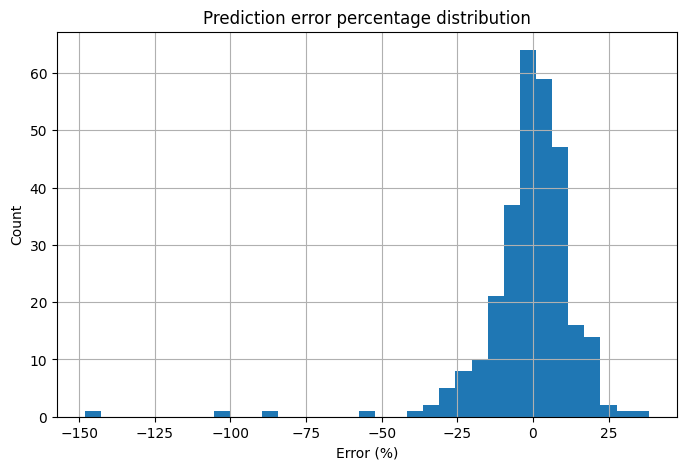

Median absolute percentage error: 6.74 %


In [25]:
# Error percentage distribution
error_percent = (residuals / y_test) * 100

plt.figure(figsize=(8, 5))
plt.hist(error_percent, bins=35)
plt.title("Prediction error percentage distribution")
plt.xlabel("Error (%)")
plt.ylabel("Count")
plt.show()

print("Median absolute percentage error:", round(np.median(np.abs(error_percent)), 2), "%")

In [26]:
# Most underpriced and overpriced predictions
diagnostic_df = pd.DataFrame({
    "Actual SalePrice": y_test,
    "Predicted SalePrice": best_predictions,
    "Residual": residuals,
    "Absolute Error": np.abs(residuals),
    "Error %": error_percent
}).sort_values("Absolute Error", ascending=False)

display(diagnostic_df.head(15))

,Actual SalePrice,Predicted SalePrice,Residual,Absolute Error,Error %
218,"311,500.00","229,826.45","81,673.55","81,673.55",26.22
774,"395,000.00","316,898.66","78,101.34","78,101.34",19.77
261,"276,000.00","345,548.88","-69,548.88","69,548.88",-25.20
70,"244,000.00","307,114.90","-63,114.90","63,114.90",-25.87
681,"159,434.00","98,433.19","61,000.81","61,000.81",38.26
30,"40,000.00","99,227.99","-59,227.99","59,227.99",-148.07
529,"200,624.00","257,522.89","-56,898.89","56,898.89",-28.36
462,"62,383.00","115,735.69","-53,352.69","53,352.69",-85.52
271,"241,500.00","188,624.26","52,875.74","52,875.74",21.89
231,"403,000.00","352,675.00","50,325.00","50,325.00",12.49


---
## 10. Explainable regression tree

The best ensemble can be powerful, but a small decision tree is easier to explain visually.

I train a compact tree only for interpretation, so I can see simple decision rules behind housing prices.

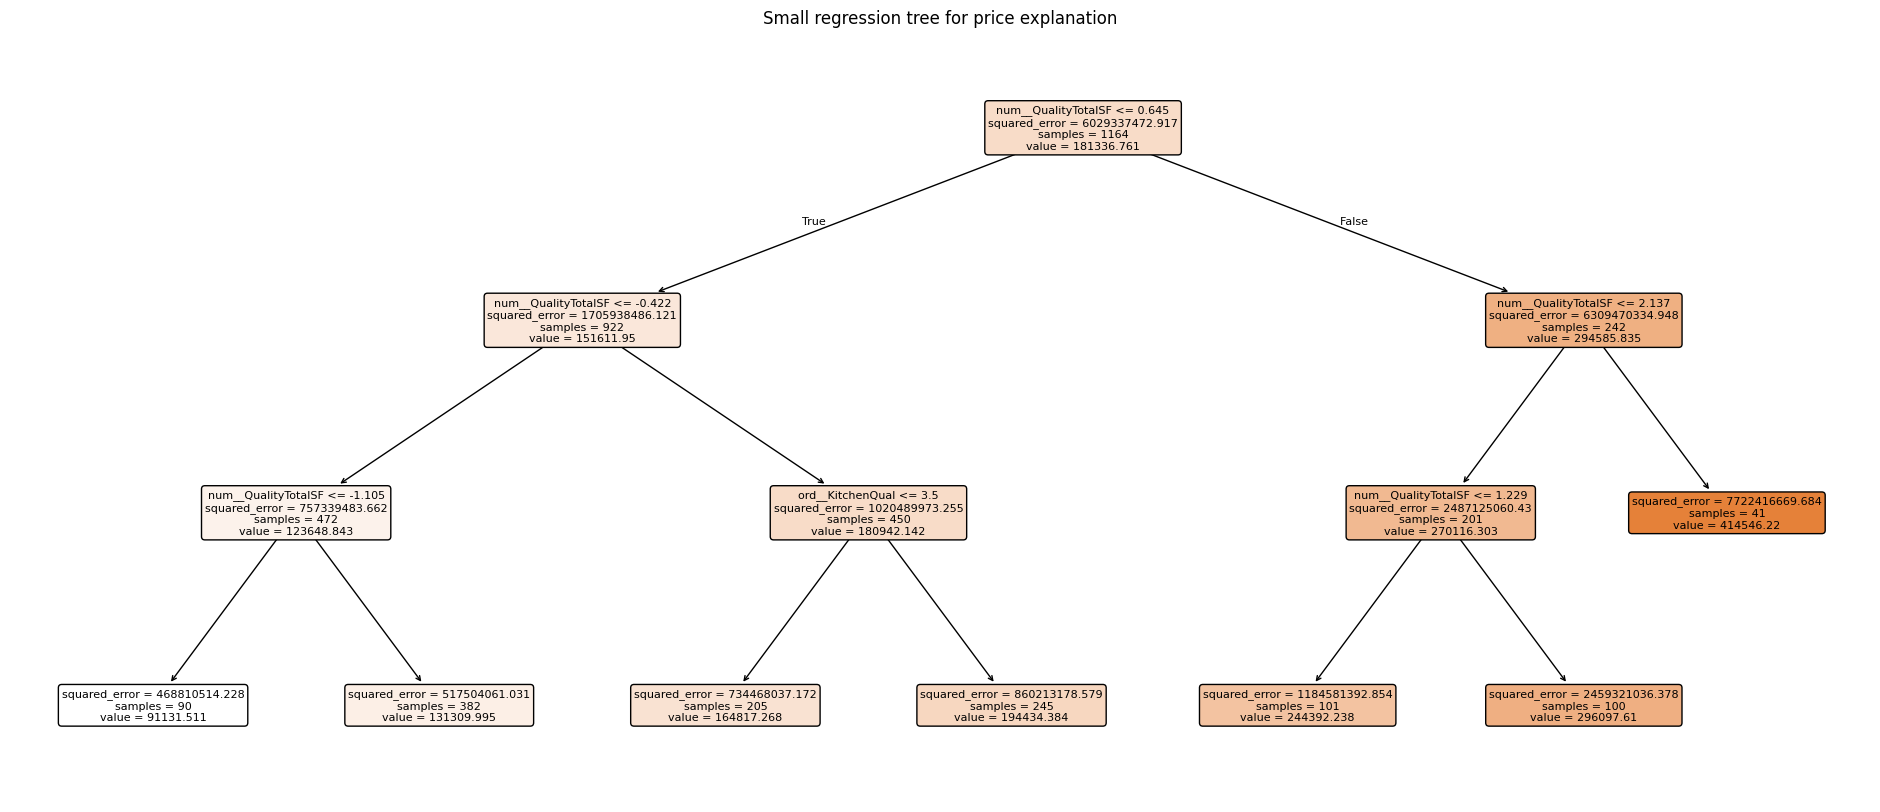

In [27]:
small_tree = Pipeline([
    ("preprocess", build_preprocessor(X_train)),
    ("model", DecisionTreeRegressor(
        max_depth=3,
        min_samples_leaf=25,
        random_state=RANDOM_STATE
    ))
])

small_tree.fit(X_train, y_train)

feature_names = small_tree.named_steps["preprocess"].get_feature_names_out()

plt.figure(figsize=(24, 10))
plot_tree(
    small_tree.named_steps["model"],
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Small regression tree for price explanation")
plt.show()

---
## 11. Feature importance

For tree-based models, I check which engineered and original features matter most.

This is one of my favorite parts because it connects the model back to real housing-market intuition.

In [28]:
if hasattr(best_model.named_steps["model"], "feature_importances_"):
    feature_names = best_model.named_steps["preprocess"].get_feature_names_out()
    importances = best_model.named_steps["model"].feature_importances_

    importance_df = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": importances
        })
        .sort_values("importance", ascending=False)
        .head(20)
    )

    display(importance_df)

    plt.figure(figsize=(10, 7))
    plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1])
    plt.title(f"Top feature importances — {best_model_name}")
    plt.xlabel("Importance")
    plt.show()
else:
    print(f"{best_model_name} does not expose feature importances directly.")

Ridge Regression does not expose feature importances directly.


---
## 12. Final takeaways

This notebook is now fully focused on **housing price regression**.

What I built:

- a clean Google Colab workflow,
- a single reliable dataset path,
- market-aware feature engineering,
- preprocessing pipelines for numeric and categorical data,
- a baseline model,
- multiple regression models,
- model comparison with MAE, RMSE, and R²,
- diagnostic plots,
- interpretable tree visualization,
- feature importance analysis.

The final result is a portfolio-ready regression project that feels practical, structured, and exciting to present on GitHub.